# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = 'train2.csv'
data = pd.read_csv("train2.csv")
data.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  int64  
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              100000 non-null  ob

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Debt_to_Income,EMI_to_Salary,Delay_Intensity
0,1,23,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",...,265,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good,0.042374,0.027152,21
1,2,23,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",...,266,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629163,Good,0.042374,0.027152,12
2,3,23,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",...,267,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good,0.042374,0.027152,21
3,4,23,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",...,268,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good,0.042374,0.027152,20
4,5,23,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",...,269,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good,0.042374,0.027152,24


In [ ]:
# 본 데이터는 수치형 변수와 범주형 변수가 함께 존재하는 신용점수 분류 데이터였기 때문에, 모델이 학습할 수 있는 형태로 전처리를 진행했습니다.
# 먼저 ID, Customer_ID, Name, SSN은 고객 식별자 성격이 강하고 예측에 직접적인 영향을 주지 않는다고 판단해서 제거했습니다.
data = data.drop(
    columns=['ID', 'Customer_ID', 'Name', 'SSN'], # 식별자 제거
    errors='ignore'
)

# 파생변수 생성

# 소득 대비 부채 부담이 얼마나 큰지가 신용점수 판단에 더 의미 있다 생각해서 소득 대비 부채 생
data['Debt_to_Income'] = data['Outstanding_Debt'] / (data['Annual_Income'] + 1)  # 소득 대비 부채
# 월급 대비 상환 부담이 얼마나 큰지가 설명력이 높다 판단했습니다.
data['EMI_to_Salary'] = data['Total_EMI_per_month'] / (data['Monthly_Inhand_Salary'] + 1)  # 월급 대비 상환 부담
# 연체 기간과 연체 빈도를 함께 반영하는 연체 강도 변수 생성
data['Delay_Intensity'] = data['Delay_from_due_date'] * data['Num_of_Delayed_Payment']  # 연체 강도


In [62]:
data.describe()

,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,4.500000,33.316340,50505.123449,4197.270835,5.368820,5.533570,14.53208,3.532880,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,2.291299,10.764812,38299.422093,3186.432497,2.593314,2.067098,8.74133,2.446356,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,1.000000,14.000000,7005.930000,303.645417,0.000000,0.000000,1.00000,0.000000,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,2.750000,24.000000,19342.972500,1626.594167,3.000000,4.000000,7.00000,2.000000,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,4.500000,33.000000,36999.705000,3095.905000,5.000000,5.000000,13.00000,3.000000,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,6.250000,42.000000,71683.470000,5957.715000,7.000000,7.000000,20.00000,5.000000,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,8.000000,56.000000,179987.280000,15204.633330,11.000000,11.000000,34.00000,9.000000,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


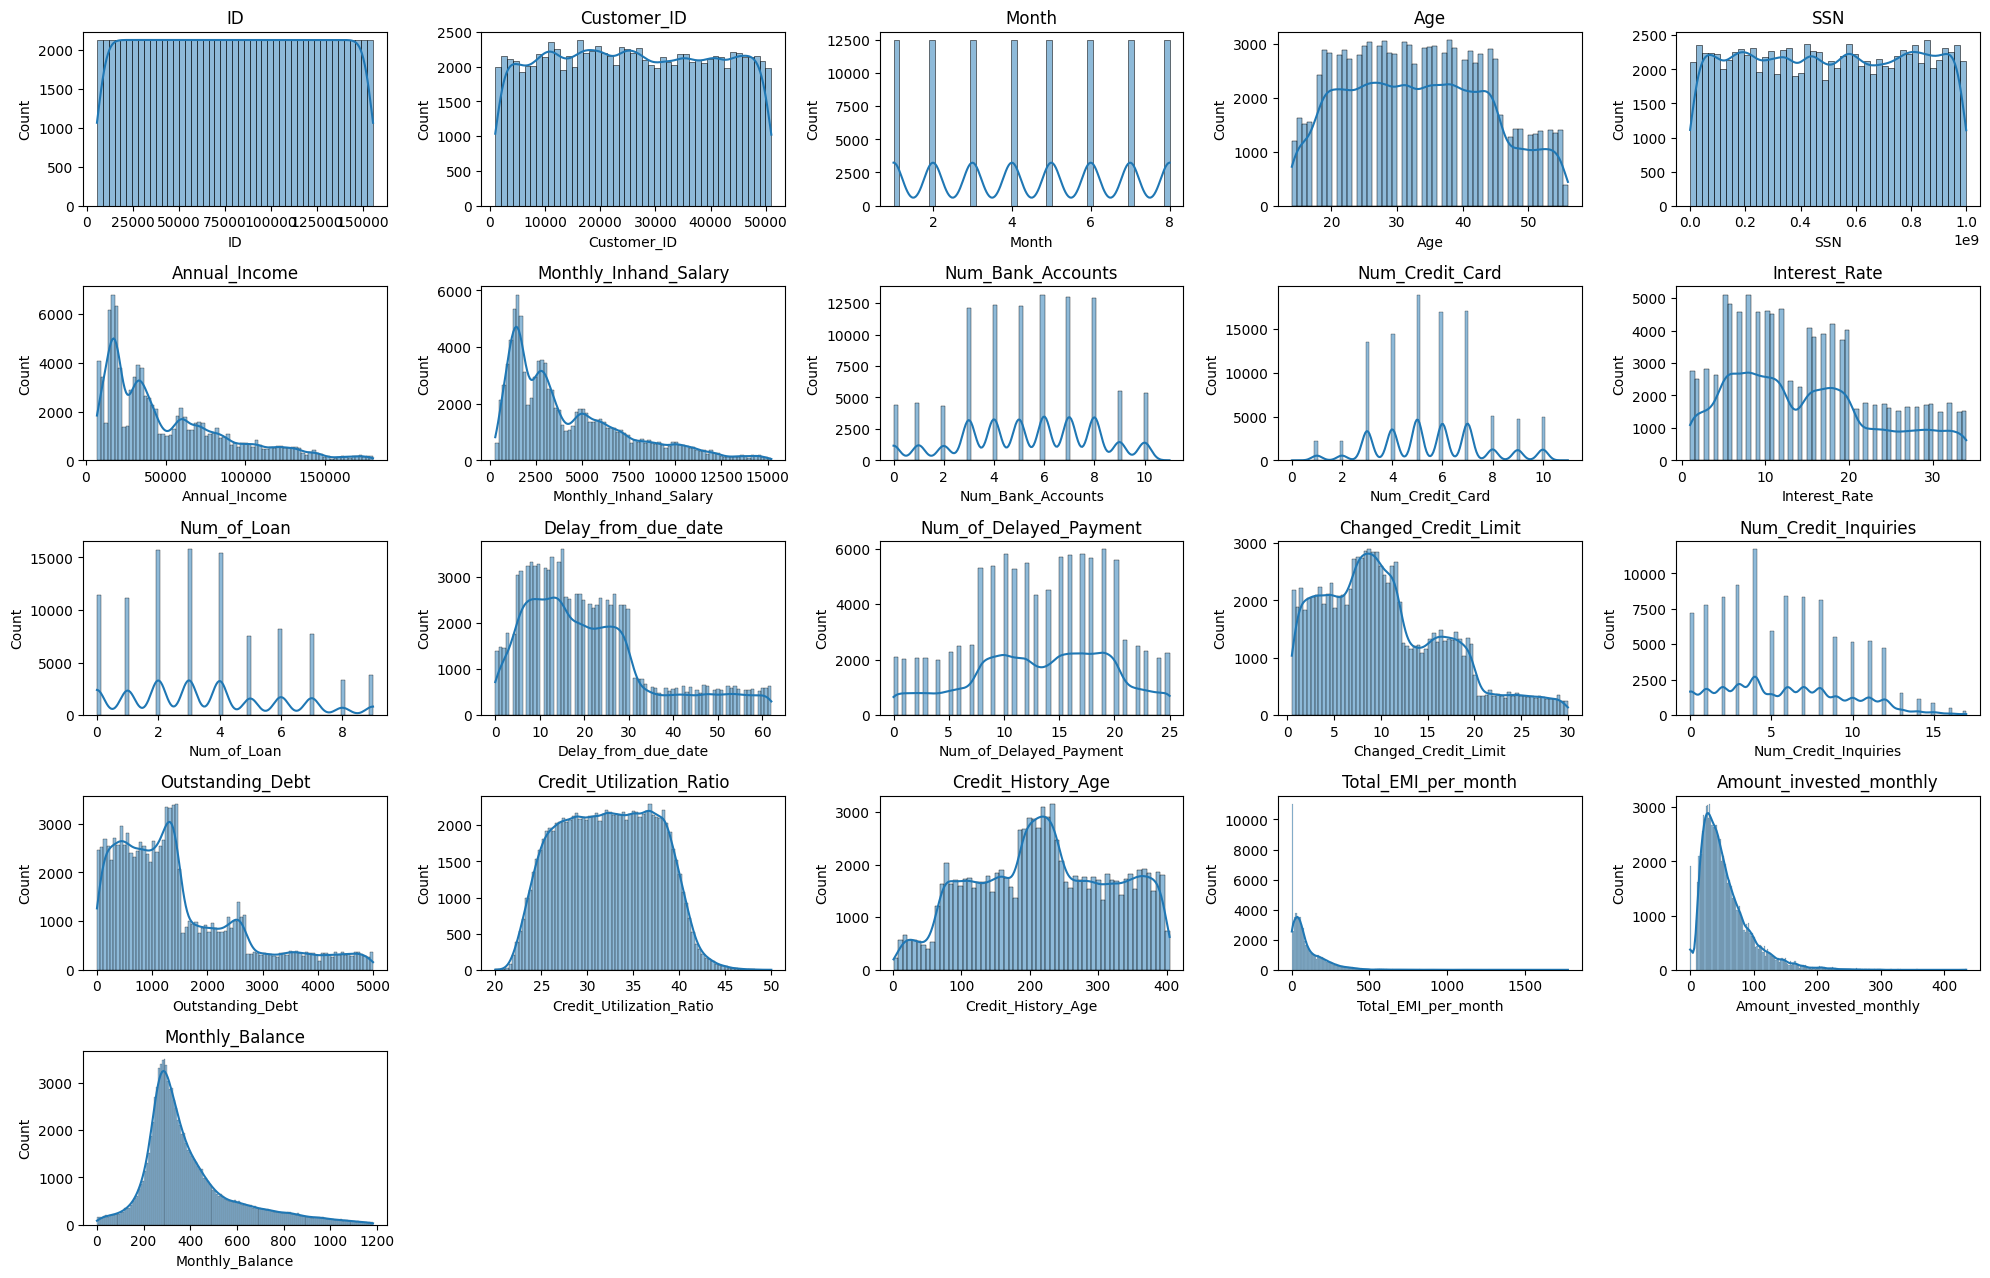

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(6, 5, i+1)
    sns.histplot(data[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

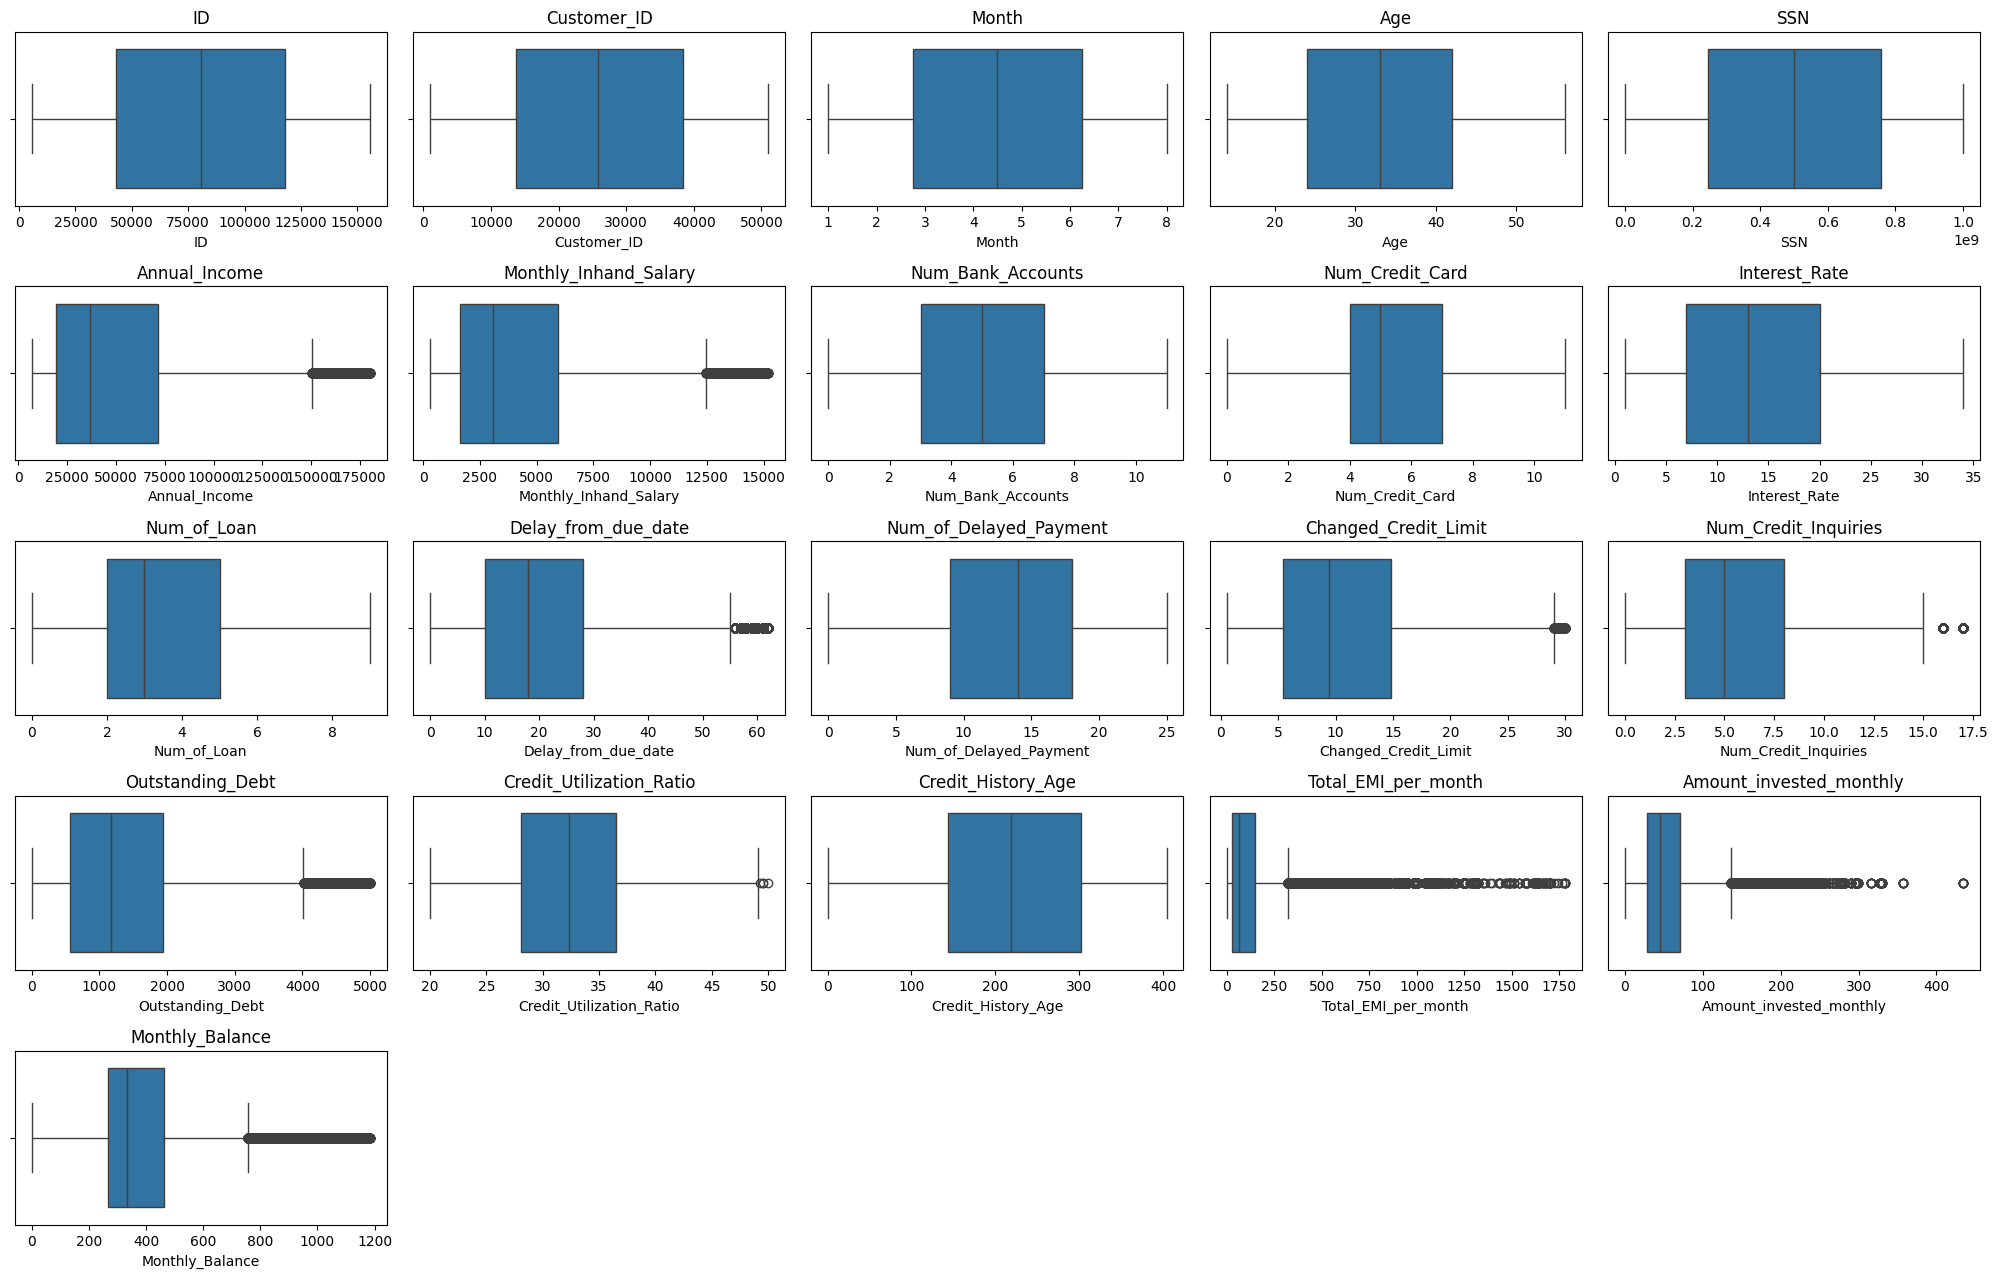

In [5]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(6, 5, i+1)
    sns.boxplot(x=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

수치형 변수의 히스토그램과 boxplot을 확인한 결과 Annual_Income, Outstanding_Debt, Total_EMI_per_month, Monthly_Balance 등 금액형 변수에서 오른쪽 꼬리와 일부 극단값이 확인되었습니다.

In [4]:
import numpy as np
import pandas as pd

# 이상치 clipping
clip_cols = [
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance'
]
# Total_EMI_per_month, Amount_invested_monthly, Monthly_Balance는 극단값의 영향이 크다고 판단하여
# 상하위 1% 기준으로 clipping을 진행했습니다.
for col in clip_cols:
    lower = data[col].quantile(0.01)  # 하위 1% 기준
    upper = data[col].quantile(0.99)  # 상위 1% 기준
    data[col] = data[col].clip(lower=lower, upper=upper)  # 극단값 완화

# 금액형 변수는 분포가 오른쪽으로 치우친 형태를 보였기 때문에 log1p 변환을 적용했습니다.
# 로그변환
log_cols = [
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Outstanding_Debt',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in log_cols:
    data[col] = np.log1p(data[col])  # 금액형 변수의 극단값 영향 완화

# Type_of_Loan은 여러 대출 유형이 한 셀에 포함되어 있어 대출 종류별 multi-hot 방식으로 분리했습니다.

# Type_of_Loan multi-hot 처리
if 'Type_of_Loan' in data.columns:

# Type_of_Loan을 그대로 원핫인코딩하면 대출 조합별 컬럼이 과도하게 생성되어 RAM 사용량 초과 되는 문제가 있었습니다.
# 그래서 ',' 기준 대출 개수 변수 생성했습니다.


    # 대출 종류 개수 생성
    data['Num_Loan_Types'] = data['Type_of_Loan'].apply(
        lambda x: len(str(x).split(','))
    )

    # 실제 대출 종류 목록
    loan_types = [
        'auto loan',
        'credit-builder loan',
        'debt consolidation loan',
        'home equity loan',
        'mortgage loan',
        'not specified',
        'payday loan',
        'personal loan',
        'student loan'
    ]

    # 대출 종류별 보유 여부 변수 생성
    for loan in loan_types:
        col_name = 'Loan_' + loan.replace(' ', '_').replace('-', '_')  # 컬럼명 정리

        data[col_name] = data['Type_of_Loan'].apply(
            lambda x: 1 if loan in str(x).lower() else 0
        ).astype('int8')  # 대출 종류별 보유 여부를 0/1로 변환하여 정보 손실 완화

    # 원본 Type_of_Loan 제거
    data = data.drop(columns=['Type_of_Loan'])

else:
    print("Type_of_Loan 컬럼은 이미 처리되었거나 삭제된 상태입니다.")


# 나머지 범주형만 원핫인코딩
categorical_columns = [
    'Occupation',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour'
]

# 이미 인코딩된 컬럼은 제외
categorical_columns = [col for col in categorical_columns if col in data.columns]

if len(categorical_columns) > 0:
    data = pd.get_dummies(
        data,
        columns=categorical_columns,
        drop_first=True,
        dtype='int8'
    )
else:
    print("원핫인코딩할 범주형 컬럼이 없습니다.")


# 확인
print(data.shape)
print(data.select_dtypes(include='object').columns.tolist())

(100000, 55)
['Credit_Score']


In [24]:
print(data['Credit_Score'].value_counts(normalize=True)) # Credit_Score 클래스 비율 확인

Credit_Score
2    0.53174
1    0.28998
0    0.17828
Name: proportion, dtype: float64


In [9]:
# Credit_Score는 2번 클래스의 비중이 가장 높고 0번 클래스의 비중이 가장 낮아 클래스 불균형이 있는 데이터였습니다.
# train, valid 분리 시 stratify를 적용하여 클래스 비율이 유지되도록 했습니다.
from sklearn.preprocessing import LabelEncoder

# Credit_Score가 아직 문자열일 때만 라벨 인코딩
if data['Credit_Score'].dtype == 'object':
    target_encoder = LabelEncoder()
    data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])  # 타겟값 숫자 변환

    print("타겟 인코딩 결과:")
    print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))
else:
    print("Credit_Score는 이미 숫자로 인코딩된 상태입니다.")

# X, y 분리
X = data.drop('Credit_Score', axis=1)  # 입력 변수
y = data['Credit_Score']               # 정답 변수

# 확인
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X 안의 object 컬럼:", X.select_dtypes(include='object').columns.tolist())

Credit_Score는 이미 숫자로 인코딩된 상태입니다.
X shape: (100000, 54)
y shape: (100000,)
X 안의 object 컬럼: []


In [10]:
# train/valid 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2, # 8 대 2
    random_state=42,
    stratify=y # 클래스 비율 유지
)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype('float32')  # train 기준으로 fit
X_valid_scaled = scaler.transform(X_valid).astype('float32')      # valid는 transform만

# Dataset 클래스
class CreditScoreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)        # 입력 tensor
        self.y = torch.tensor(y.values, dtype=torch.long)    # 정답 tensor

    def __len__(self):
        return len(self.y)                                   # 데이터 개수

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]                      # 한 샘플 반환

# DataLoader 생성
train_dataset = CreditScoreDataset(X_train_scaled, y_train)
valid_dataset = CreditScoreDataset(X_valid_scaled, y_valid)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

# 확인
batch_X, batch_y = next(iter(train_loader))

print("X_train_scaled:", X_train_scaled.shape)
print("X_valid_scaled:", X_valid_scaled.shape)
print("batch_X shape:", batch_X.shape)
print("batch_y shape:", batch_y.shape)
print("입력 변수 개수:", batch_X.shape[1])
print("클래스 개수:", len(torch.unique(batch_y)))

X_train_scaled: (80000, 54)
X_valid_scaled: (20000, 54)
batch_X shape: torch.Size([64, 54])
batch_y shape: torch.Size([64])
입력 변수 개수: 54
클래스 개수: 3


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

# GPU 사용 가능하면 GPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)


# 개선 MLP 모델 정의
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()

        self.layer1 = nn.Linear(input_size, 256)  # 입력층 -> 첫 번째 은닉층
        self.bn1 = nn.BatchNorm1d(256)            # 학습 안정화

        self.layer2 = nn.Linear(256, 128)         # 첫 번째 은닉층 -> 두 번째 은닉층
        self.bn2 = nn.BatchNorm1d(128)            # 학습 안정화

        self.layer3 = nn.Linear(128, 64)          # 두 번째 은닉층 -> 세 번째 은닉층
        self.bn3 = nn.BatchNorm1d(64)             # 학습 안정화

        self.layer4 = nn.Linear(64, 3)            # 출력층, 클래스 3개

        self.relu = nn.ReLU()                     # 활성화 함수
        self.dropout = nn.Dropout(0.2)            # 과적합 방지, 기존 0.3보다 약간 낮춤

    def forward(self, x):
        x = self.layer1(x)                        # 첫 번째 선형 변환
        x = self.bn1(x)                           # BatchNorm 적용
        x = self.relu(x)                          # ReLU 적용
        x = self.dropout(x)                       # Dropout 적용

        x = self.layer2(x)                        # 두 번째 선형 변환
        x = self.bn2(x)                           # BatchNorm 적용
        x = self.relu(x)                          # ReLU 적용
        x = self.dropout(x)                       # Dropout 적용

        x = self.layer3(x)                        # 세 번째 선형 변환
        x = self.bn3(x)                           # BatchNorm 적용
        x = self.relu(x)                          # ReLU 적용
        x = self.dropout(x)                       # Dropout 적용

        x = self.layer4(x)                        # 최종 출력
        return x

사용 장치: cuda


In [18]:
input_size = X_train_scaled.shape[1]              # 입력 변수 개수 자동 반영, 현재 54개

model = MLP(input_size).to(device)                # 모델 생성 후 GPU/CPU로 이동

criterion = nn.CrossEntropyLoss()                 # 다중분류 손실함수

# 클래스 불균형을 고려하여 가중치를 적용한 CrossEntropyLoss도 실험해봤습니다.
# 해당 방식은 소수 클래스 예측은 보완하지만 전체 valid score가 오히려 감소 했습니다..
# 따라서 최종 모델에서는 class weight를 적용하지 않은 기본 CrossEntropyLoss를 사용했습니다.

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0005,                                     # learning rate
    weight_decay=1e-4                             # 과적합 완화
)

print("입력 변수 개수:", input_size)
print(model)


입력 변수 개수: 54
MLP(
  (layer1): Linear(in_features=54, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer4): Linear(in_features=64, out_features=3, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


| 실험 | 주요 변경점 | Validation Accuracy |
|---|---|---|
| Baseline MLP | 기본 전처리 + 단순 MLP | 약 71% |
| 개선 1 | Type_of_Loan multi-hot 적용 | 약 75% |
| 개선 2 | 파생변수 추가 + 개선 MLP | 약 75.27% |
| 개선 3 | lr=0.0005, epoch 50 | 약 78~80% |
| 최종 | lr=0.0005, epoch 100, best model 저장 | 81.19% |

learning rate는 0.001과 0.0005를 비교했습니다. 0.0005는 초반 학습 속도는 느렸지만 epoch을 늘렸을 때 성능이 더 안정적으로 상승했습니다.

In [20]:
# 이전 50 epoch 학습 후 model을 새로 만들지 않고 그대로 추가 학습을 진행함
# 그래서 100 epoch 루프의 1번째 epoch부터 valid score가 약 78% 수준에서 시작함
# 최종 모델은 validation accuracy가 가장 높았던 시점의 모델로 저장함

epochs = 100  # 최대 100 epoch까지 학습

best_valid_acc = 0.0  # 최고 검증 정확도 저장
best_epoch = 0        # 최고 성능 epoch 저장
patience = 15         # 15 epoch 동안 개선 없으면 중단
patience_counter = 0  # 개선 없는 epoch 카운트

for epoch in range(epochs):
    model.train()  # 학습 모드
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs = inputs.to(device)    # 입력 데이터를 장치로 이동
        targets = targets.to(device)  # 정답 데이터를 장치로 이동

        optimizer.zero_grad()         # 이전 gradient 초기화

        outputs = model(inputs)       # 모델 예측
        loss = criterion(outputs, targets)  # 손실 계산

        loss.backward()               # 역전파
        optimizer.step()              # 가중치 업데이트

        running_loss += loss.item()   # loss 누적

        _, predicted = torch.max(outputs, 1)  # 예측 클래스
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    model.eval()  # 평가 모드
    correct_valid = 0
    total_valid = 0

    with torch.no_grad():  # 검증에서는 gradient 계산 안 함
        for inputs, targets in valid_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total_valid += targets.size(0)
            correct_valid += (predicted == targets).sum().item()

    avg_loss = running_loss / len(train_loader)  # 평균 loss
    train_accuracy = 100 * correct_train / total_train  # 학습 정확도
    valid_accuracy = 100 * correct_valid / total_valid  # 검증 정확도

    # 최고 성능 갱신 여부 확인
    if valid_accuracy > best_valid_acc:
        best_valid_acc = valid_accuracy
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), "best_mlp_model.pth")  # 최고 모델 저장
    else:
        patience_counter += 1

    print(
        f'Epoch [{epoch+1}/{epochs}], '
        f'Loss: {avg_loss:.4f}, '
        f'학습 정확도: {train_accuracy:.2f}%, '
        f'검증 정확도: {valid_accuracy:.2f}%, '
        f'Best: {best_valid_acc:.2f}% at epoch {best_epoch}'
    )

    # early stopping
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

Epoch [1/100], Loss: 0.5174, 학습 정확도: 76.96%, 검증 정확도: 77.72%, Best: 77.72% at epoch 1
Epoch [2/100], Loss: 0.5169, 학습 정확도: 77.02%, 검증 정확도: 78.36%, Best: 78.36% at epoch 2
Epoch [3/100], Loss: 0.5152, 학습 정확도: 77.29%, 검증 정확도: 77.85%, Best: 78.36% at epoch 2
Epoch [4/100], Loss: 0.5124, 학습 정확도: 77.44%, 검증 정확도: 78.27%, Best: 78.36% at epoch 2
Epoch [5/100], Loss: 0.5115, 학습 정확도: 77.25%, 검증 정확도: 78.35%, Best: 78.36% at epoch 2
Epoch [6/100], Loss: 0.5109, 학습 정확도: 77.36%, 검증 정확도: 78.42%, Best: 78.42% at epoch 6
Epoch [7/100], Loss: 0.5114, 학습 정확도: 77.30%, 검증 정확도: 78.14%, Best: 78.42% at epoch 6
Epoch [8/100], Loss: 0.5128, 학습 정확도: 77.20%, 검증 정확도: 78.79%, Best: 78.79% at epoch 8
Epoch [9/100], Loss: 0.5067, 학습 정확도: 77.70%, 검증 정확도: 78.96%, Best: 78.96% at epoch 9
Epoch [10/100], Loss: 0.5080, 학습 정확도: 77.52%, 검증 정확도: 78.67%, Best: 78.96% at epoch 9
Epoch [11/100], Loss: 0.5084, 학습 정확도: 77.56%, 검증 정확도: 78.58%, Best: 78.96% at epoch 9
Epoch [12/100], Loss: 0.5070, 학습 정확도: 77.61%, 검증 정확도: 79.16%, B

In [22]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

model.load_state_dict(torch.load("best_mlp_model.pth"))  # epoch 95의 best 모델 로드
model.eval()  # 평가 모드

all_preds = []    # 전체 예측값 저장
all_targets = []  # 전체 실제값 저장

with torch.no_grad():  # 평가에서는 gradient 계산 안 함
    for inputs, targets in valid_loader:
        inputs = inputs.to(device)                # 입력 데이터를 장치로 이동
        targets = targets.to(device)              # 정답 데이터를 장치로 이동

        outputs = model(inputs)                   # 모델 예측
        _, predicted = torch.max(outputs, 1)      # 예측 클래스 선택

        all_preds.extend(predicted.cpu().numpy()) # 예측값 저장
        all_targets.extend(targets.cpu().numpy()) # 실제값 저장

valid_acc = accuracy_score(all_targets, all_preds)                 # 검증 정확도
macro_f1 = f1_score(all_targets, all_preds, average='macro')       # Macro F1
weighted_f1 = f1_score(all_targets, all_preds, average='weighted') # Weighted F1

print("Valid Accuracy:", valid_acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

print("\nClassification Report")
print(classification_report(all_targets, all_preds))

print("\nConfusion Matrix")
print(confusion_matrix(all_targets, all_preds))

Valid Accuracy: 0.81195
Macro F1: 0.8081035434174941
Weighted F1: 0.8121094523170092

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.84      0.79      3566
           1       0.77      0.88      0.82      5799
           2       0.87      0.77      0.81     10635

    accuracy                           0.81     20000
   macro avg       0.79      0.83      0.81     20000
weighted avg       0.82      0.81      0.81     20000


Confusion Matrix
[[2982   25  559]
 [  30 5100  669]
 [1001 1477 8157]]


info()를 봤을때 본 데이터는 표 형태 데이터였고 행과 열로 구성된 데이터에서 어떤 컬럼이 중요한지 선택하면서 학습하도록 설계된 모델인 TabNet을 사용하면 MLP보다 성능이 개선될 가능성이 있다고 판단해서 사용했습니다.

그러나 기본 TabNet 실험에서는 validation score가 약 70% 수준으로 나타났습니다.

이후 TabNet 구조에 더 적합한 입력 방식으로 원핫 인코딩 대신 모델 내부에서 임베딩 벡터로 변환하여 학습하는 방식도 사용해봤지만, 해당 방식에서도 MLP모델과 큰 성능차이는 없다고 판단하여 최종 모델로 사용하지는 않았습니다.

##최종 결과 해석

###클래스 0
precision: 0.74
recall: 0.84
f1-score: 0.79

0 → 0으로 예측: 2982개 /
0 → 2로 오분류: 559개

### 클래스 1

precision: 0.77
recall: 0.88
f1-score: 0.82

1 → 1로 예측: 5100개
1 → 2로 오분류: 669개

### 클래스 2
precision: 0.87
recall: 0.77
f1-score: 0.81

 2 → 2로 예측: 8157개
 2 → 0으로 오분류: 1001개
 2 → 1로 오분류: 1477개

최종 MLP 모델은 validation accuracy 81.19%, macro F1 0.808, weighted F1 0.812를 기록했습니다. Accuracy와 F1-score가 비슷한 수준으로 나타나 특정 클래스에만 치우친 성능이 아니라 전체 클래스에서 비교적 균형 있는 예측 성능을 보였습니다. 클래스별로는 1번 클래스의 recall이 0.88로 가장 높아 실제 1번 클래스를 잘 식별했으며, 2번 클래스는 precision이 0.87로 가장 높아 2번으로 예측한 경우의 신뢰도가 높았습니다. 다만 confusion matrix를 보면 실제 2번 클래스가 0번 또는 1번으로 오분류되는 경우가 상대적으로 많아, 클래스 2의 recall 개선은 향후 보완점으로 볼 수 있습니다.